<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/3_2_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 3 – DataFrame operations and relationships between variables (Part 2)

In the previous sections, we learned how to transform and summarize tabular data.
Now we move one level further:

**we are not only computing numbers**, but also learning
how to turn summary statistics into **meaningful information**.

In this notebook, we examine the same phenomenon (Titanic survival)
from multiple perspectives:

- **pivot + heatmap** → quick overview across two dimensions
- **melt + barplot** → the same data in *tidy* form, seaborn-friendly
- **boxplot** → distributions instead of averages (median, spread, outliers)
- **countplot** → sample size: how much can we trust the averages?
- **error bar** → mean and variability together
- **lineplot** → trends across an ordered categorical variable (`pclass`: 1 → 2 → 3)

The goal is not to learn as many plot types as possible,
but to learn how to ask the *right questions*:

- What does the plot show — and what does it not?
- How large is the underlying sample?
- Can an average be misleading?
- When does it make sense to talk about a “trend” across categories?

### The Titanic dataset

The Titanic dataset is one of the most well-known open-source datasets and is frequently used for practicing data processing, statistical analysis, and machine learning.  
It contains information about the passengers of the RMS Titanic, which sank on April 15, 1912, and focuses on identifying who survived the disaster.

#### Dataset characteristics

- **Source:** OpenML, originally based on Kaggle and various statistical publications  
- **Number of rows:** 1,309 passengers  
- **Number of columns:** 14 features  

#### Dataset columns

- **pclass** – Passenger class (1 = first, 2 = second, 3 = third class)  
- **sex** – Passenger gender (`male`, `female`)  
- **age** – Passenger age (some values are missing)  
- **sibsp** – Number of siblings and spouses aboard  
- **parch** – Number of parents and children aboard  
- **fare** – Ticket price (in pounds)  
- **embarked** – Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton)  
- **home.dest** – Passenger’s home or destination  
- **survived** – Target variable (0 = did not survive, 1 = survived)  

#### Interesting facts about Titanic survival data

- First-class passengers had a much higher survival rate than third-class passengers.  
- Women had a significantly higher chance of survival than men.  
- Due to the “women and children first” rule, younger passengers were more likely to survive the disaster.

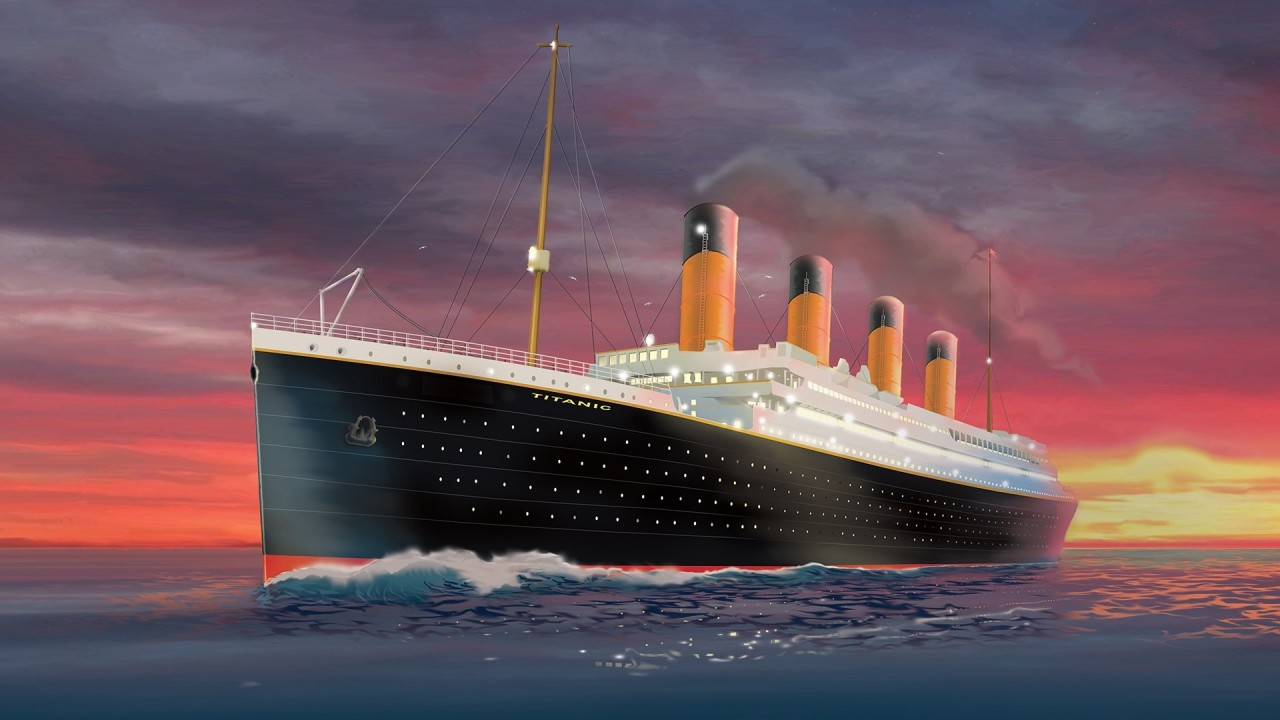

In [ ]:
# Loading the Titanic dataset using scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd

# Load the data from the OpenML repository
titanic = fetch_openml(name="titanic", version=1, as_frame=True)

# Convert the data to a Pandas DataFrame
df = titanic.data

# Attach the target variable (y) and convert it to numeric format
df["survived"] = pd.to_numeric(titanic.target, errors="coerce")

# More details about the Titanic dataset:
# https://medium.com/data-science/machine-learning-with-the-titanic-dataset-7f6909e58280

# More details about sklearn.datasets:
# https://scikit-learn.org/stable/api/sklearn.datasets.html

## Heatmap from a pivot table – visualizing two-variable groupings

Using `pivot_table`, we have already computed the survival rate
by gender (`sex`) and passenger class (`pclass`).

We now visualize this summary table as a **heatmap**, where:
- rows and columns represent the grouping dimensions,
- colors encode the aggregated values (survival rate).

Heatmaps are particularly well suited for the quick and intuitive
interpretation of **two-variable groupings**.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pivot table: average survival rate by gender and passenger class
pt = pd.pivot_table(
    df,
    index="sex",          # rows: gender
    columns="pclass",     # columns: passenger class
    values="survived",    # variable of interest
    aggfunc="mean",       # survival rate = mean
    observed=False
)


In [ ]:
pt

pclass,1,2,3
sex,,,
female,0.965278,0.886792,0.490741
male,0.340782,0.146199,0.152130


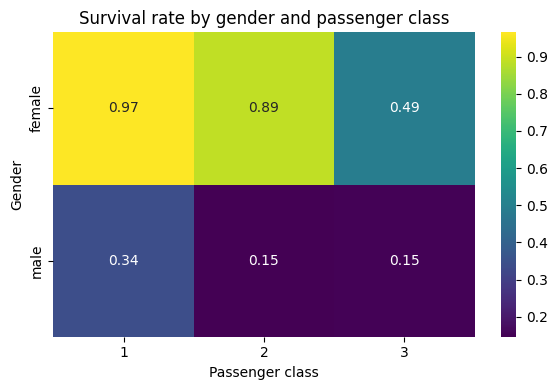

In [ ]:
# Create the heatmap
plt.figure(figsize=(6, 4))    # set figure size
sns.heatmap(
    pt,                       # pivot table to display
    annot=True,               # show values inside the cells
    fmt=".2f",                # two decimal places
    cmap="viridis"            # color scale
)

# Axis labels and title
plt.title("Survival rate by gender and passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Gender")

plt.tight_layout()            # adjust layout
plt.show()                    # display the plot

### How should we interpret the plot?

Each cell in the plot represents the
average survival rate for a specific group.

Using color intensity, we can quickly identify:
- more and less favorable groups,
- differences across genders and passenger classes.

It is important to emphasize that a heatmap displays
**summary statistics** only:
it does not show sample size or the shape of the distributions.
Therefore, interpretation always requires additional context.

## Melt → Barplot – the same information from a different perspective

A pivot table is excellent for summarization, but many visualization tools
(e.g. seaborn) prefer data in a **long (tidy) format**.

In this step, we transform the pivot table into a long format using `melt`,
and then visualize the survival rate with a bar plot
by passenger class and gender.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pivot table: survival rate by gender and passenger class
pt = pd.pivot_table(
    df,
    index="sex",          # rows: gender
    columns="pclass",     # columns: passenger class
    values="survived",    # variable of interest
    aggfunc="mean",       # survival rate = mean
    observed=False
)

# Convert the index back into a column
# Wide format → long format
pt_long = (
    pt.reset_index()      # move 'sex' back to a regular column
      .melt(
          id_vars="sex",              # identifier variable
          var_name="pclass",          # new name for former column labels
          value_name="survival_rate"  # name of the value column
      )
)

pt_long

,sex,pclass,survival_rate
0,female,1,0.965278
1,male,1,0.340782
2,female,2,0.886792
3,male,2,0.146199
4,female,3,0.490741
5,male,3,0.152130


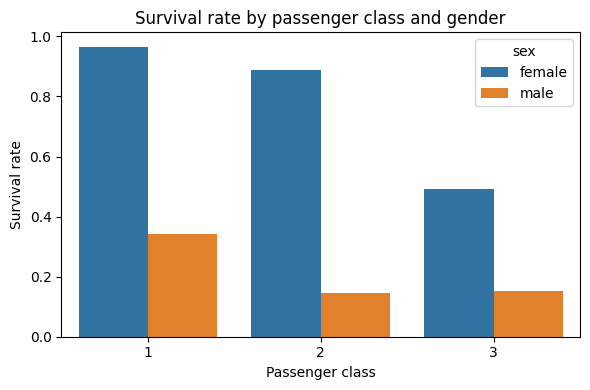

In [ ]:
# Create a bar plot
plt.figure(figsize=(6, 4))     # set figure size
sns.barplot(
    data=pt_long,              # data in long format
    x="pclass",                # x-axis: passenger class
    y="survival_rate",         # y-axis: survival rate
    hue="sex"                  # grouping by gender
)

# Title and axis labels
plt.title("Survival rate by passenger class and gender")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")

plt.tight_layout()             # adjust layout
plt.show()                     # display the plot


### What do we learn from this?

The bar plot shows the same information as the heatmap,
but with a different visual emphasis:
- comparisons across passenger classes are made via bar heights,
- gender differences are highlighted using separate colors.

This example illustrates that:
- visualization often **requires data transformation**,
- `melt` plays a key role in preparing data for plotting.


## Aggregated distributions – Boxplot

So far, the plots we have used (heatmap, bar plot) have shown
**summary statistics**, typically averages.

However, a single number often hides the true structure of the data.
For this reason, we now examine the **distributions** using a **boxplot**,
which simultaneously shows:
- the median,
- the spread (variability),
- and outliers.

This helps us understand that
very different distributions may exist
even when the averages are similar.


In [ ]:
df.describe()

,pclass,age,sibsp,parch,fare,body,survived
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000,1309.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917,0.381971
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922,0.486055
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000,0.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000,1.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000,1.000000


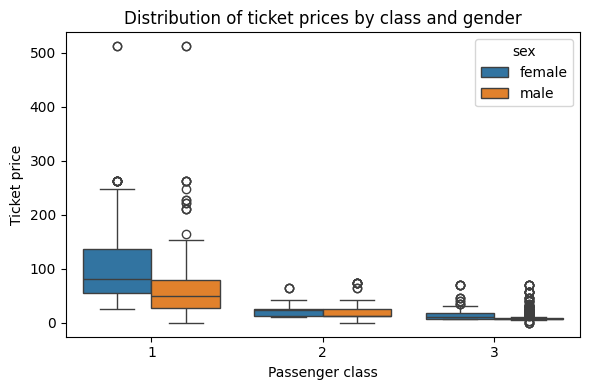

In [ ]:
# Create a boxplot to examine the distribution of ticket prices
plt.figure(figsize=(6, 4))     # set figure size

sns.boxplot(
    data=df,                   # full dataset
    x="pclass",                # x-axis: passenger class
    y="fare",                  # y-axis: ticket price
    hue="sex"                  # grouping by gender
)

# Title and axis labels
plt.title("Distribution of ticket prices by class and gender")
plt.xlabel("Passenger class")
plt.ylabel("Ticket price")

plt.tight_layout()             # adjust layout
plt.show()                     # display the plot



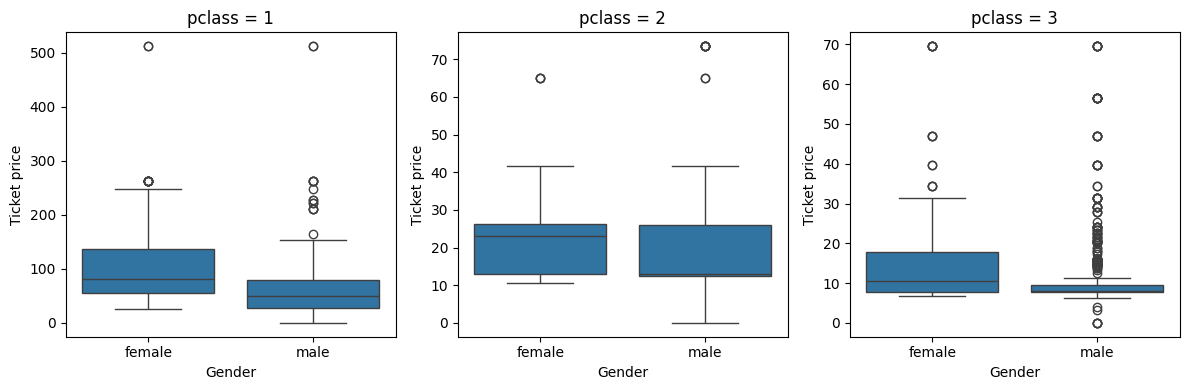

In [ ]:
# Three subplots side by side (pclass = 1, 2, 3)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for ax, p in zip(axes, sorted(df["pclass"].dropna().unique())):
    # Select data for the given passenger class
    sub = df[df["pclass"] == p]

    # Boxplot by gender
    sns.boxplot(
        data=sub,
        x="sex",
        y="fare",
        ax=ax
    )

    ax.set_title(f"pclass = {p}")
    ax.set_xlabel("Gender")
    ax.set_ylabel("Ticket price")

plt.tight_layout()
plt.show()

### How should we interpret the boxplot?

The box represents the middle 50% of the data (the interquartile range),
the line marks the median, and the points indicate outliers.

From the plot, we can clearly see that:
- ticket prices across passenger classes differ not only in their averages,
  but also in their distributions,
- outliers can strongly influence the mean.

For this reason, during data analysis it is always worth
examining distributions as well,
not just summary statistics.


### Note:

- Outliers visible in a boxplot are not necessarily errors; they may reflect natural properties of the data.
- Handling outliers (e.g. keeping them, removing them, or applying transformations)
  is an important analytical decision that can significantly affect
  statistical measures and model behavior.
- We will discuss outlier handling in detail in the next chapter.

## Groupby → Countplot – visualizing sample size

- The plots used so far (heatmap, bar plot, boxplot) have shown aggregated statistics
  (means and distributions).
- To interpret these results properly, however, it is essential to know
  **how large the underlying sample is**.
- In this step, we visualize the **number of observations** in each group,
  which helps assess the reliability of the aggregated results.


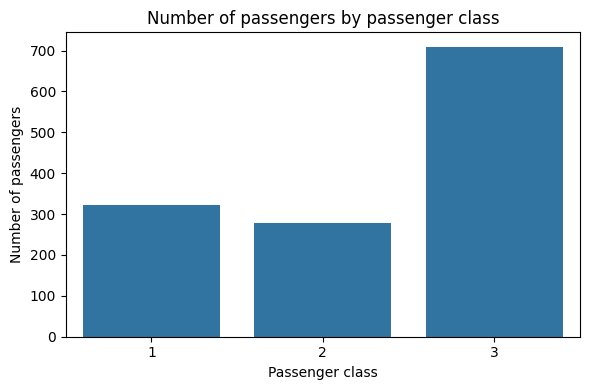

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(6, 4))     # set figure size

sns.countplot(
    data=df,                   # data source
    x="pclass"                 # category: passenger class
)

# Title and axis labels
plt.title("Number of passengers by passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Number of passengers")

plt.tight_layout()             # adjust layout
plt.show()                     # display the plot


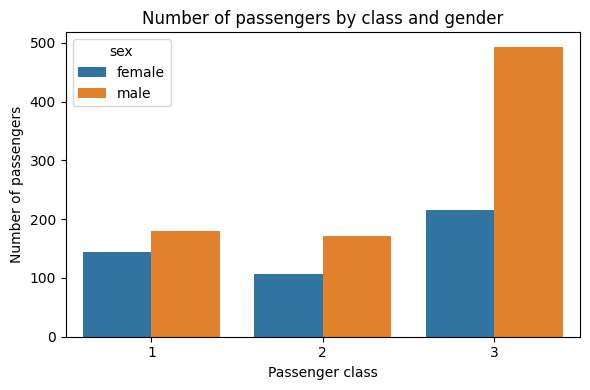

In [ ]:
# Grouped bar chart: number of passengers by class and gender
plt.figure(figsize=(6, 4))     # set figure size

sns.countplot(
    data=df,                   # data source
    x="pclass",                # x-axis: passenger class
    hue="sex"                  # split by gender
)

# Title and axis labels
plt.title("Number of passengers by class and gender")
plt.xlabel("Passenger class")
plt.ylabel("Number of passengers")

plt.tight_layout()             # adjust layout
plt.show()                     # display the plot


### Why is this plot important?

The count plot shows the sample size
for each group.

This is crucial for interpretation:
- in groups with small sample sizes, averages and proportions
  are less reliable,
- larger groups allow for more stable conclusions.

For this reason, aggregated statistics should always be interpreted
in the context of sample size.

## Groupby → Lineplot – trends across ordered categories

Line plots are often automatically associated with time series,
but they are **not limited to temporal data**.

If a categorical variable has a **natural order**
(e.g. passenger class: 1 → 2 → 3),
a line plot can be useful for visualizing trends.

In this example, we examine
how an aggregated metric changes
along the ordered categories.


In [ ]:
# Group the data by passenger class
# Compute the mean of the 'survived' variable (survival rate)
# Convert the index back into a regular column
# Sort the result by passenger class
survival_by_class = (
    df.groupby("pclass")["survived"]
      .mean()
      .reset_index()
      .sort_values("pclass")
)

survival_by_class


,pclass,survived
0,1,0.619195
1,2,0.429603
2,3,0.255289


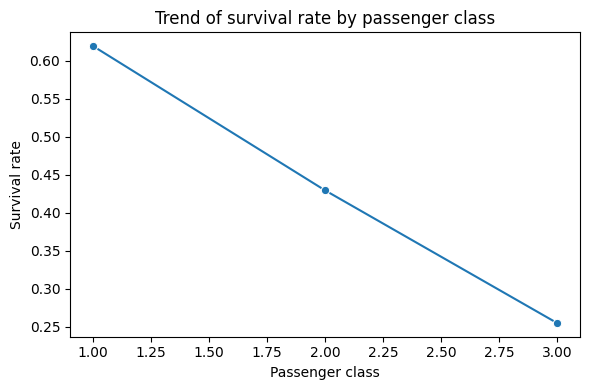

In [ ]:
# Create the plot
plt.figure(figsize=(6, 4))     # set figure size

sns.lineplot(
    data=survival_by_class,    # data aggregated by passenger class
    x="pclass",                # x-axis: passenger class
    y="survived",              # y-axis: survival rate
    marker="o"                 # mark points at each category
)

# Title and axis labels
plt.title("Trend of survival rate by passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")

plt.tight_layout()             # adjust layout
plt.show()                     # display the plot

### Exercises – Iris dataset

### The Iris dataset

The Iris dataset is a classic dataset in machine learning and data analysis.
It contains 150 flower samples belonging to three different iris species
(*setosa*, *versicolor*, *virginica*).

Each flower sample is described by four features:

- **sepal.length** – sepal length (cm)  
- **sepal.width** – sepal width (cm)  
- **petal.length** – petal length (cm)  
- **petal.width** – petal width (cm)  
- **variety** – iris species name

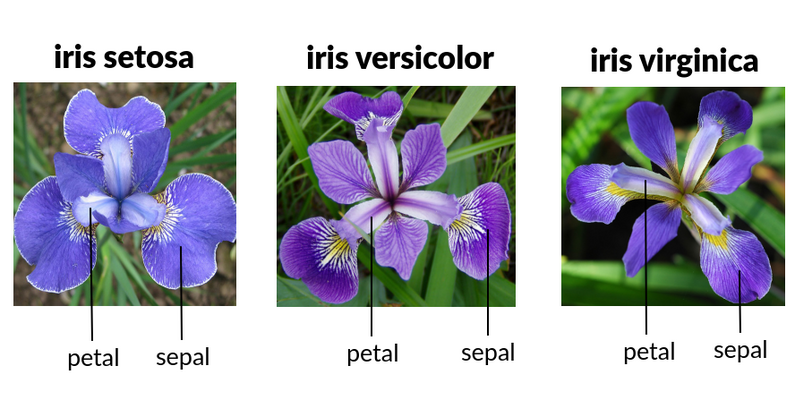

In [ ]:
from sklearn.datasets import load_iris, load_wine, load_diabetes
iris = load_iris(as_frame=True)
df_iris = iris.frame
df_iris["species"] = df_iris["target"].map(dict(enumerate(iris.target_names)))


### Task 1

- Group the data by species
- Compute the mean sepal length (cm) for each species
- Visualize the result using a line plot
- Interpret the result: can we meaningfully talk about a “trend” in this case?

      species  sepal length (cm)
0      setosa              5.006
1  versicolor              5.936
2   virginica              6.588


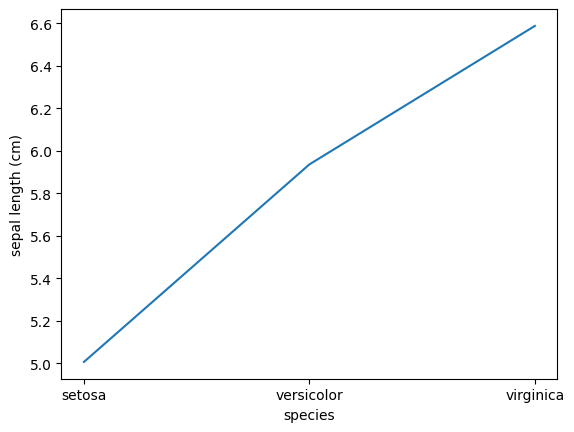

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, load_diabetes

iris = load_iris(as_frame=True)
df_iris = iris.frame
df_iris["species"] = df_iris["target"].map(dict(enumerate(iris.target_names)))

t1 = df_iris.groupby("species")["sepal length (cm)"].mean().reset_index()
print(t1)
sns.lineplot(data=t1, x="species", y="sepal length (cm)")
plt.show()

### Task 2 (binning + groupby + bar plot)

- Create a new categorical column based on petal length (cm)  
  (small / medium / large using `pd.cut`)
- Count how many samples fall into each bin
- Visualize the result using a bar plot
- Which category is dominant?

petal_cat
medium    54
small     50
large     46
Name: count, dtype: int64


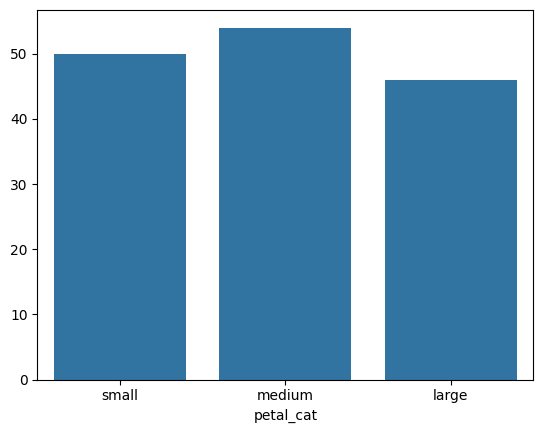

In [2]:
df_iris["petal_cat"] = pd.cut(df_iris["petal length (cm)"], bins=3, labels=["small","medium","large"])
t2 = df_iris["petal_cat"].value_counts()
print(t2)
sns.barplot(x=t2.index, y=t2.values)
plt.show()

### Task 3 – Wine dataset (groupby + mean + heatmap from a pivot table)

- Create a pivot table with:
  - index: `wine_class`
  - values: `alcohol`, `color_intensity`
  - aggfunc: `mean`
- Visualize the result as a heatmap
- Which class is strong in which attribute?

In [ ]:
# Load the data
wine = load_wine(as_frame=True)
df_wine = wine.frame
df_wine["wine_class"] = df_wine["target"]

              alcohol  color_intensity
wine_class                            
0           13.744746         5.528305
1           12.278732         3.086620
2           13.153750         7.396250


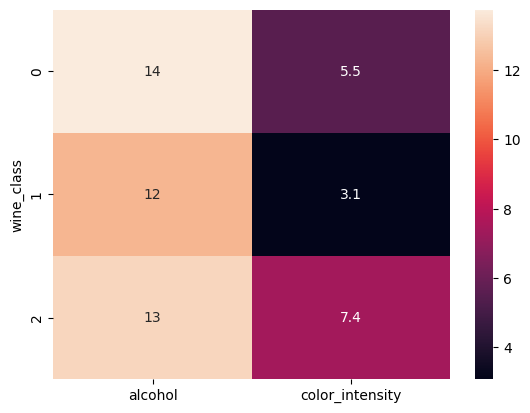

In [3]:
wine = load_wine(as_frame=True)
df_wine = wine.frame
df_wine["wine_class"] = df_wine["target"]

t3 = pd.pivot_table(df_wine, index="wine_class", values=["alcohol","color_intensity"], aggfunc="mean")
print(t3)
sns.heatmap(t3, annot=True)
plt.show()

### Task 4 – Wine dataset (groupby → error bar)

- Group the data by `wine_class`
- Compute the mean and standard deviation of `alcohol`
- Create an error bar plot
- Where is the uncertainty the largest?

   wine_class       mean       std
0           0  13.744746  0.462125
1           1  12.278732  0.537964
2           2  13.153750  0.530241


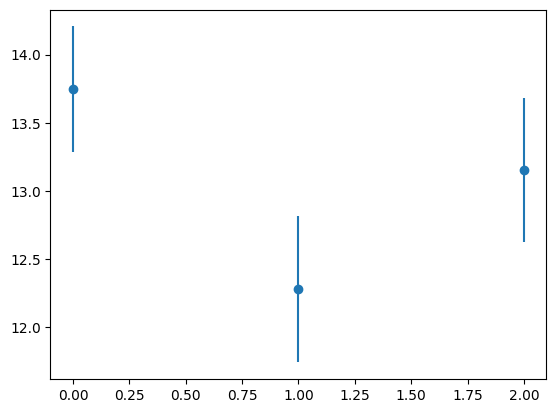

In [4]:
t4 = df_wine.groupby("wine_class")["alcohol"].agg(["mean","std"]).reset_index()
print(t4)
plt.errorbar(t4["wine_class"], t4["mean"], yerr=t4["std"], fmt='o')
plt.show()

### Task 5 – Diabetes dataset (groupby + melt → boxplot)

- Create bins from the `age` variable (e.g. 3 categories)
- Group the data by these bins
- Select two numerical variables
- Transform the data into *long format* using `melt`
- Create a boxplot
- What does the plot reveal about variability?

In [ ]:
# Load the data
diabetes = load_diabetes(as_frame=True)
df_diab = diabetes.frame

  age_bin       bmi        bp
0   young -0.012341 -0.023061
1  middle  0.003082  0.003345
2     old  0.007377  0.018987


/tmp/ipykernel_23051/3272122731.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t5 = df_diab.groupby("age_bin")[["bmi","bp"]].mean().reset_index()


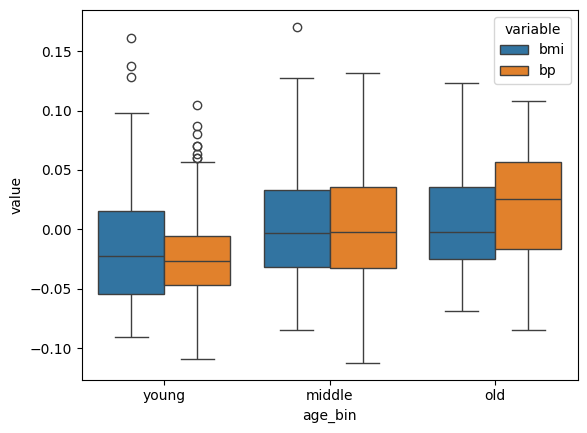

In [5]:
diabetes = load_diabetes(as_frame=True)
df_diab = diabetes.frame

df_diab["age_bin"] = pd.cut(df_diab["age"], bins=3, labels=["young","middle","old"])
t5 = df_diab.groupby("age_bin")[["bmi","bp"]].mean().reset_index()
print(t5)

melted = df_diab.melt(id_vars="age_bin", value_vars=["bmi","bp"])
sns.boxplot(data=melted, x="age_bin", y="value", hue="variable")
plt.show()